# Notebook 02 — DEM and Terrain Preparation

## Objective

This notebook prepares the Digital Elevation Model (DEM) required for
deriving topographic and hydrological flood-conditioning factors for the
Lucknow + 20 km study area.

The primary DEM source selected for the study is the Copernicus DEM
GLO-30, with approximately 30 m spatial resolution.

The DEM will subsequently be used to derive:

- Elevation
- Slope
- Flow direction
- Flow accumulation

Elevation and slope are derived from the DEM clipped to the defined
study area. Hydrological derivatives are calculated from the available
DEM coverage after hydrological conditioning.

## 1. Import Required Libraries

The following libraries are used for raster processing, spatial analysis,
visualization, and file management.

In [1]:
import os
from pathlib import Path

import numpy as np
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt

from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling

## 2. Define Project Paths

The DEM is stored in the raw-data directory because it is an original
downloaded dataset and should not be modified directly.

Processed DEM products will be stored separately in the processed-data
directory.

In [2]:
PROJECT_ROOT = Path.cwd().parent

DEM_RAW = PROJECT_ROOT / "data" / "raw" / "DEM"
DEM_PROCESSED = PROJECT_ROOT / "data" / "processed" / "notebook_02"

STUDY_AREA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_01"
    / "Lucknow_Search_Area_20km.gpkg"
)

DEM_PROCESSED.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw DEM folder:", DEM_RAW)
print("Processed DEM folder:", DEM_PROCESSED)
print("Study area:", STUDY_AREA_PATH)

Project root: d:\Projects\GeoAI-Flood-Susceptibility
Raw DEM folder: d:\Projects\GeoAI-Flood-Susceptibility\data\raw\DEM
Processed DEM folder: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02
Study area: d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_01\Lucknow_Search_Area_20km.gpkg


## 3. Identify the Downloaded DEM

The downloaded DEM is stored in the raw DEM directory. The file is
identified programmatically so that the workflow does not depend on a
manually entered filename.

In [3]:
print("DEM folder exists:", DEM_RAW.exists())
print("DEM folder:", DEM_RAW)

print("\nFiles inside DEM folder:")
for file in DEM_RAW.iterdir():
    print(file.name)

DEM folder exists: True
DEM folder: d:\Projects\GeoAI-Flood-Susceptibility\data\raw\DEM

Files inside DEM folder:
output_hh.tif


In [4]:
dem_files = list(DEM_RAW.glob("*.tif")) + list(DEM_RAW.glob("*.tiff"))

print("DEM files found:")

for file in dem_files:
    print(file)

DEM files found:
d:\Projects\GeoAI-Flood-Susceptibility\data\raw\DEM\output_hh.tif


## 4. Load and Inspect the DEM

The DEM is opened using Rasterio. Before processing, its spatial
reference, resolution, dimensions, extent, data type, and elevation
statistics are inspected.

This step is important because terrain derivatives should not be
calculated until the input DEM has been verified.

In [5]:
dem_path = dem_files[0]

with rasterio.open(dem_path) as src:
    dem = src.read(1)
    dem_profile = src.profile.copy()
    dem_crs = src.crs
    dem_transform = src.transform
    dem_bounds = src.bounds
    dem_width = src.width
    dem_height = src.height
    dem_resolution = src.res
    dem_nodata = src.nodata

print("DEM:", dem_path.name)
print("CRS:", dem_crs)
print("Dimensions:", dem_width, "x", dem_height)
print("Resolution:", dem_resolution)
print("Bounds:", dem_bounds)
print("NoData:", dem_nodata)
print("Data type:", dem.dtype)
print("Minimum elevation:", np.nanmin(dem))
print("Maximum elevation:", np.nanmax(dem))

DEM: output_hh.tif
CRS: EPSG:4326
Dimensions: 4724 x 3199
Resolution: (0.0002777777777777778, 0.0002777777777777778)
Bounds: BoundingBox(left=80.35263887777776, bottom=26.37819445555555, right=81.66486109999998, top=27.26680556666666)
NoData: None
Data type: float32
Minimum elevation: 88.0
Maximum elevation: 151.91898


## 5. Inspect the Study Area

The study area represents the Lucknow + 20 km analysis domain established
in Notebook 01.

Its coordinate reference system and spatial extent are checked before
using it to clip the DEM.


In [6]:
study_area = gpd.read_file(STUDY_AREA_PATH)

# Assign the known CRS without changing the coordinates
study_area = study_area.set_crs("EPSG:32644", allow_override=True)

print("Study area CRS:", study_area.crs)
print("Number of features:", len(study_area))
print("Bounds:", study_area.total_bounds)
print("Geometry valid:", study_area.geometry.is_valid.all())

Study area CRS: EPSG:32644
Number of features: 1
Bounds: [ 463358.57983883 2938218.33094633  526062.35561871 2998994.24737365]
Geometry valid: True


## 6. Reproject DEM to EPSG:32644

The downloaded DEM is provided in geographic coordinates (EPSG:4326),
while the project study area uses WGS 84 / UTM Zone 44N (EPSG:32644).

The DEM is reprojected to EPSG:32644 so that distance, area, slope, and
hydrological calculations are performed in a projected coordinate system
with metre-based units.

In [7]:
TARGET_CRS = "EPSG:32644"
reprojected_dem_path = DEM_PROCESSED / "DEM_Lucknow_UTM44N.tif"

with rasterio.open(dem_path) as src:

    src_nodata = src.nodata

    transform, width, height = calculate_default_transform(
        src.crs,
        TARGET_CRS,
        src.width,
        src.height,
        *src.bounds
    )

    profile = src.profile.copy()

    profile.update({
        "driver": "GTiff",
        "crs": TARGET_CRS,
        "transform": transform,
        "width": width,
        "height": height,
        "nodata": -9999.0,
        "dtype": "float32"
    })

    with rasterio.open(reprojected_dem_path, "w", **profile) as dst:

        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=src_nodata,
            dst_transform=transform,
            dst_crs=TARGET_CRS,
            dst_nodata=-9999.0,
            resampling=Resampling.bilinear
        )

print("Reprojected DEM saved to:")
print(reprojected_dem_path)

Reprojected DEM saved to:
d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02\DEM_Lucknow_UTM44N.tif


## 7. Validate Reprojected DEM

The reprojected DEM is checked to confirm that its CRS, dimensions,
resolution, and elevation values are valid before clipping it to the
study area.

In [8]:
with rasterio.open(reprojected_dem_path) as src:

    dem_utm = src.read(1, masked=True)

    print("CRS:", src.crs)
    print("Dimensions:", src.width, "x", src.height)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("Minimum elevation:", dem_utm.min())
    print("Maximum elevation:", dem_utm.max())

CRS: EPSG:32644
Dimensions: 4571 x 3443
Resolution: (28.635052567985024, 28.635052567985024)
Bounds: BoundingBox(left=435421.62257714855, bottom=2917571.419897918, right=566312.4478654081, top=3016161.9058894906)
Minimum elevation: 88.0
Maximum elevation: 150.46147


## 8. Clip DEM to the Lucknow + 20 km Study Area

The reprojected DEM is clipped to the predefined Lucknow + 20 km study
area. This reduces the raster to the actual spatial domain used in the
flood-susceptibility analysis.

In [9]:
clipped_dem_path = PROJECT_ROOT / "data" / "processed" / "notebook_02" / "DEM_Lucknow_20km.tif"

with rasterio.open(reprojected_dem_path) as src:

    study_area_utm = study_area.to_crs(src.crs)

    clipped_dem, clipped_transform = mask(
        src,
        study_area_utm.geometry,
        crop=True,
        nodata=-9999
    )

    clipped_profile = src.profile.copy()

    clipped_profile.update({
        "height": clipped_dem.shape[1],
        "width": clipped_dem.shape[2],
        "transform": clipped_transform,
        "nodata": -9999
    })

    with rasterio.open(clipped_dem_path, "w", **clipped_profile) as dst:
        dst.write(clipped_dem)

print("Clipped DEM saved to:")
print(clipped_dem_path)

Clipped DEM saved to:
d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02\DEM_Lucknow_20km.tif


In [10]:
with rasterio.open(clipped_dem_path) as src:

    clipped = src.read(1, masked=True)

    print("CRS:", src.crs)
    print("Dimensions:", src.width, "x", src.height)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)
    print("Minimum elevation:", clipped.min())
    print("Maximum elevation:", clipped.max())

CRS: EPSG:32644
Dimensions: 2191 x 2123
Resolution: (28.635052567985024, 28.635052567985024)
Bounds: BoundingBox(left=463340.7988309339, bottom=2938217.292799435, right=526080.1990073891, top=2999009.5094012674)
NoData: -9999.0
Minimum elevation: 99.5
Maximum elevation: 144.42026


## 9. Visualize the Clipped DEM

The clipped DEM is visualized to verify its spatial pattern and confirm
that the elevation surface covers the intended Lucknow + 20 km study
area without obvious processing artifacts.

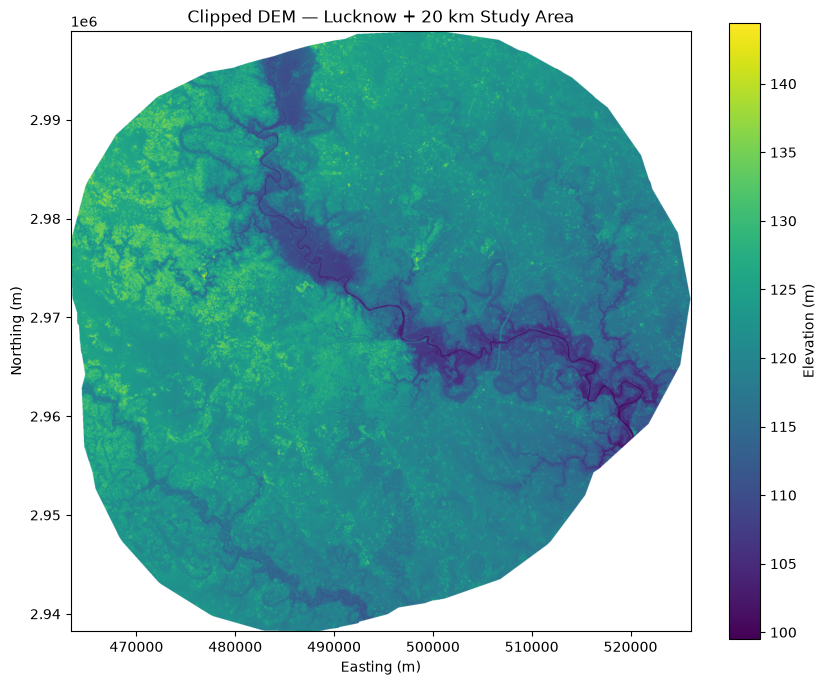

In [11]:
FIGURES_DIR = PROJECT_ROOT/"outputs"/"figures"/"notebook_02"
with rasterio.open(clipped_dem_path) as src:
    dem_plot = src.read(1, masked=True)

plt.figure(figsize=(10, 8))

plt.imshow(
    dem_plot,
    extent=[
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    ]
)

plt.colorbar(label="Elevation (m)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Clipped DEM — Lucknow + 20 km Study Area")

plt.savefig(FIGURES_DIR/"Clipped_DEM_20km")
plt.show()

## 10. Elevation Factor

The clipped DEM represents the elevation factor for the flood-susceptibility
analysis.

The prepared elevation raster covers the Lucknow + 20 km study area and is
stored in EPSG:32644 with approximately 28.7 m spatial resolution.

No additional transformation is applied at this stage. Any normalization
or reclassification of elevation will be performed later during the
susceptibility modelling stage.

## 11. Slope

Slope is derived from the prepared DEM and expressed in degrees.

The calculation uses the elevation change between neighboring DEM cells
and the horizontal cell dimensions. The resulting slope raster represents
the local terrain steepness across the study area.

Slope will not be reclassified or normalized at this stage.

In [12]:
slope_path = PROJECT_ROOT / "data" / "processed" / "notebook_02" / "Slope_Lucknow_20km.tif"

with rasterio.open(clipped_dem_path) as src:

    elevation = src.read(1, masked=True).astype("float32")
    profile = src.profile.copy()

    xres = src.transform.a
    yres = abs(src.transform.e)

    # Calculate terrain gradient
    elevation_array = elevation.filled(np.nan)

    dz_dy, dz_dx = np.gradient(
        elevation_array,
        yres,
        xres
    )

    # Calculate slope in radians
    slope_radians = np.arctan(
        np.sqrt(dz_dx**2 + dz_dy**2)
    )

    # Convert radians to degrees
    slope_degrees = np.degrees(slope_radians)

    # Mask both original NoData areas and NaN values
    slope_masked = np.ma.masked_invalid(slope_degrees)
    slope_masked = np.ma.masked_where(
        elevation.mask,
        slope_masked
    )

    profile.update(
        dtype="float32",
        count=1,
        nodata=-9999.0
    )

    with rasterio.open(slope_path, "w", **profile) as dst:

        dst.write(
            slope_masked.filled(-9999).astype("float32"),
            1
        )

print("Corrected slope raster saved to:")
print(slope_path)

Corrected slope raster saved to:
d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02\Slope_Lucknow_20km.tif


## 12. Validate Slope

The derived slope raster is checked for its coordinate reference system,
resolution, NoData value, and numerical range before visualization.

In [13]:
with rasterio.open(slope_path) as src:

    slope = src.read(1, masked=True)

    print("CRS:", src.crs)
    print("Dimensions:", src.width, "x", src.height)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Minimum slope:", slope.min())
    print("Maximum slope:", slope.max())
    print("Mean slope:", slope.mean())
    print("Valid pixels:", slope.count())

CRS: EPSG:32644
Dimensions: 2191 x 2123
Resolution: (28.635052567985024, 28.635052567985024)
NoData: -9999.0
Minimum slope: 0.0
Maximum slope: 24.54817
Mean slope: 1.5657840063200845
Valid pixels: 3631597


## 12. Visualize Slope

The derived slope raster is visualized to verify its spatial distribution
and identify any obvious processing artifacts before it is used as a
flood-susceptibility conditioning factor.

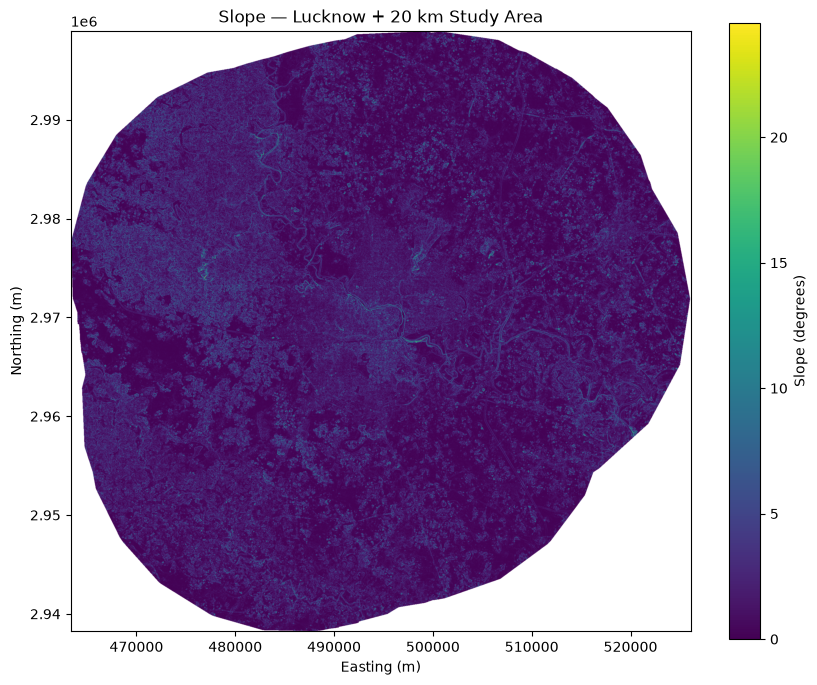

In [14]:
with rasterio.open(slope_path) as src:
    slope_plot = src.read(1, masked=True)

plt.figure(figsize=(10, 8))

plt.imshow(
    slope_plot,
    extent=[
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    ]
)

plt.colorbar(label="Slope (degrees)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("Slope — Lucknow + 20 km Study Area")

plt.savefig(FIGURES_DIR/"Slope — Lucknow + 20 km Study Area")
plt.show()

## 13. Hydrological Analysis DEM

For hydrological analysis, the corrected reprojected DEM is used as the
elevation surface.

The analysis is restricted to the spatial extent covered by the available
DEM. Areas outside this DEM coverage are not included in the hydrological
analysis.

In [15]:
import whitebox

wbt = whitebox.WhiteboxTools()

print("WhiteboxTools version:", wbt.version())

WhiteboxTools version: WhiteboxTools v2.4.0 (c) Dr. John Lindsay 2017-2023

WhiteboxTools is an advanced geospatial data analysis platform developed at
the University of Guelph's Geomorphometry and Hydrogeomatics Research 
Group (GHRG). See www.whiteboxgeo.com for more details.



## 14. Hydrological Conditioning — Fill Depressions

Small depressions in a DEM can interrupt continuous drainage paths.
The DEM is hydrologically conditioned by filling depressions before
deriving flow direction and flow accumulation.

The conditioned DEM is used only for the hydrological derivatives.
The original elevation DEM remains unchanged and is retained as the
elevation factor.

In [16]:
filled_dem_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_02"
    / "DEM_Lucknow_hydrologically_conditioned.tif"
)

wbt.fill_depressions(
    dem=str(reprojected_dem_path),
    output=str(filled_dem_path)
)

print("Conditioned DEM saved to:")
print(filled_dem_path)

.\whitebox_tools.exe --run="FillDepressions" --dem='d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02\DEM_Lucknow_UTM44N.tif' --output='d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02\DEM_Lucknow_hydrologically_conditioned.tif' --fix_flats -v --compress_rasters=False

******************************
* Welcome to FillDepressions *
* Powered by WhiteboxTools   *
* www.whiteboxgeo.com        *
******************************
Reading data...
Finding pit cells: 8%
Finding pit cells: 16%
Finding pit cells: 25%
Finding pit cells: 33%
Finding pit cells: 41%
Finding pit cells: 50%
Finding pit cells: 58%
Finding pit cells: 66%
Finding pit cells: 75%
Finding pit cells: 83%
Finding pit cells: 91%
Finding pit cells: 100%
Filling depressions: 0%
Filling depressions: 1%
Filling depressions: 2%
Filling depressions: 3%
Filling depressions: 4%
Filling depressions: 5%
Filling depressions: 6%
Filling depressions: 7%
Filling depressions: 8%
Filling depressions: 9%
Filling de

In [17]:
with rasterio.open(filled_dem_path) as src:

    filled_dem = src.read(1, masked=True)

    print("CRS:", src.crs)
    print("Dimensions:", src.width, "x", src.height)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Minimum elevation:", filled_dem.min())
    print("Maximum elevation:", filled_dem.max())

CRS: EPSG:32644
Dimensions: 4571 x 3443
Resolution: (28.635052567985024, 28.635052567985024)
NoData: -9999.0
Minimum elevation: 96.11199188232422
Maximum elevation: 150.4614715576172


## 15. D8 Flow Direction from Conditioned DEM

D8 flow direction is recalculated using the hydrologically conditioned
DEM. This ensures that artificial depressions in the elevation surface
do not unnecessarily interrupt the modeled drainage network.

In [18]:
flow_direction_conditioned_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_02"
    / "Flow_Direction_Lucknow_conditioned.tif"
)

wbt.d8_pointer(
    dem=str(filled_dem_path),
    output=str(flow_direction_conditioned_path)
)

print("Conditioned flow direction saved to:")
print(flow_direction_conditioned_path)

.\whitebox_tools.exe --run="D8Pointer" --dem='d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02\DEM_Lucknow_hydrologically_conditioned.tif' --output='d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02\Flow_Direction_Lucknow_conditioned.tif' -v --compress_rasters=False

****************************
* Welcome to D8Pointer     *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Progress: 20%
Progress: 21%
Progress: 22%
Progress: 23%
Progress: 24%
Progress: 25%
Progress: 26%
Progress: 27%
Progress: 28%
Progress: 29%
Progress: 30%
Progress: 31%
Progress: 32%
Progress: 33%
Progress: 34%
Progress: 35%
Progress: 36%
Progress: 37%
Progress: 38%
Pr

In [19]:
with rasterio.open(flow_direction_conditioned_path) as src:

    flow_direction_conditioned = src.read(1, masked=True)

    print("CRS:", src.crs)
    print("Dimensions:", src.width, "x", src.height)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Valid pixels:", flow_direction_conditioned.count())
    print("Unique values:")
    print(np.unique(flow_direction_conditioned.compressed()))

CRS: EPSG:32644
Dimensions: 4571 x 3443
Resolution: (28.635052567985024, 28.635052567985024)
NoData: -32768.0
Valid pixels: 15651906
Unique values:
[  0   1   2   4   8  16  32  64 128]


## 16. D8 Flow Accumulation from Conditioned DEM

Flow accumulation is calculated from the D8 flow-direction raster derived
from the hydrologically conditioned DEM.

The accumulation value represents the number of upstream DEM cells
contributing flow to each cell. Higher values indicate greater
concentration of surface runoff.

In [20]:
flow_accumulation_conditioned_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_02"
    / "Flow_Accumulation_Lucknow_conditioned.tif"
)

wbt.d8_flow_accumulation(
    i=str(flow_direction_conditioned_path),
    output=str(flow_accumulation_conditioned_path),
    out_type="cells",
    pntr=True
)

print("Corrected flow accumulation saved to:")
print(flow_accumulation_conditioned_path)

.\whitebox_tools.exe --run="D8FlowAccumulation" --input='d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02\Flow_Direction_Lucknow_conditioned.tif' --output='d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_02\Flow_Accumulation_Lucknow_conditioned.tif' --out_type=cells --pntr -v --compress_rasters=False

*********************************
* Welcome to D8FlowAccumulation *
* Powered by WhiteboxTools      *
* www.whiteboxgeo.com           *
*********************************
Reading data...
Flow directions: 0%
Flow directions: 1%
Flow directions: 2%
Flow directions: 3%
Flow directions: 4%
Flow directions: 5%
Flow directions: 6%
Flow directions: 7%
Flow directions: 8%
Flow directions: 9%
Flow directions: 10%
Flow directions: 11%
Flow directions: 12%
Flow directions: 13%
Flow directions: 14%
Flow directions: 15%
Flow directions: 16%
Flow directions: 17%
Flow directions: 18%
Flow directions: 19%
Flow directions: 20%
Flow directions: 21%
Flow directions: 22%
Flow d

In [21]:
with rasterio.open(flow_accumulation_conditioned_path) as src:

    flow_accumulation_final = src.read(1, masked=True)

    print("CRS:", src.crs)
    print("Dimensions:", src.width, "x", src.height)
    print("Resolution:", src.res)
    print("NoData:", src.nodata)
    print("Minimum accumulation:", flow_accumulation_final.min())
    print("Maximum accumulation:", flow_accumulation_final.max())
    print("Mean accumulation:", flow_accumulation_final.mean())
    print("Valid pixels:", flow_accumulation_final.count())

CRS: EPSG:32644
Dimensions: 4571 x 3443
Resolution: (28.635052567985024, 28.635052567985024)
NoData: -32768.0
Minimum accumulation: 1.0
Maximum accumulation: 7.007395e+06
Mean accumulation: 3215.5216715459446
Valid pixels: 15651906


## 17. Visualize Flow Accumulation

The D8 flow-accumulation raster is visualized using a logarithmic
transformation to make both low- and high-accumulation drainage pathways
visible.

The visualization is used to verify whether the modeled drainage network
has a spatially coherent pattern.

C:\Users\ANSHIKA\AppData\Local\Temp\ipykernel_11068\1976613867.py:5: RuntimeWarning: invalid value encountered in log1p
  accumulation_log = np.log1p(accumulation)


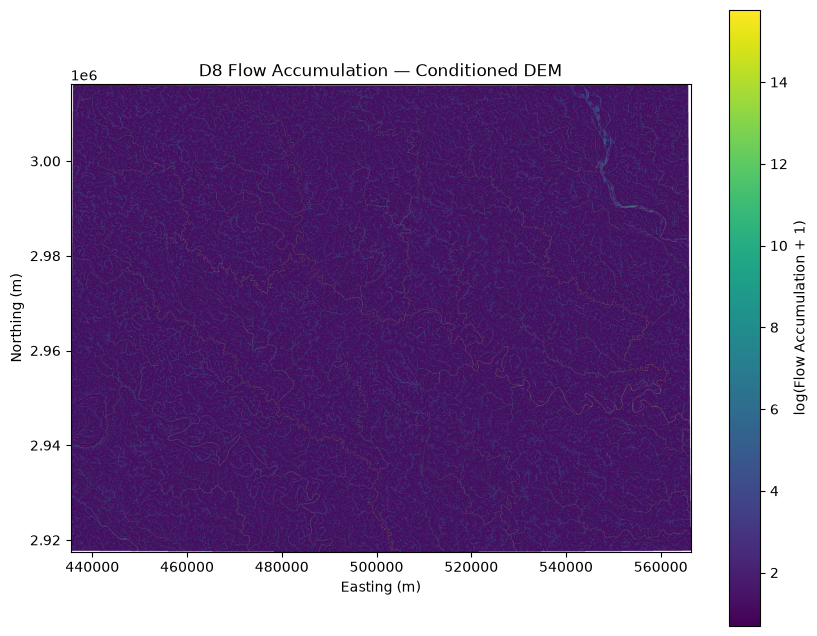

In [22]:
with rasterio.open(flow_accumulation_conditioned_path) as src:
    accumulation = src.read(1, masked=True)

# Log transformation for visualization
accumulation_log = np.log1p(accumulation)

plt.figure(figsize=(10, 8))

plt.imshow(
    accumulation_log,
    extent=[
        src.bounds.left,
        src.bounds.right,
        src.bounds.bottom,
        src.bounds.top
    ]
)

plt.colorbar(label="log(Flow Accumulation + 1)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title("D8 Flow Accumulation — Conditioned DEM")

plt.show()

## 18. Validation Against the Gomti River Network

The DEM-derived flow-accumulation network is compared spatially with the
Gomti River network identified in Notebook 01.

This comparison provides a qualitative validation of the hydrological
routing derived from the DEM before the flow-accumulation factor is used
in the flood-susceptibility analysis.

C:\Users\ANSHIKA\AppData\Local\Temp\ipykernel_11068\1394772538.py:50: RuntimeWarning: invalid value encountered in log1p
  np.log1p(high_accumulation),


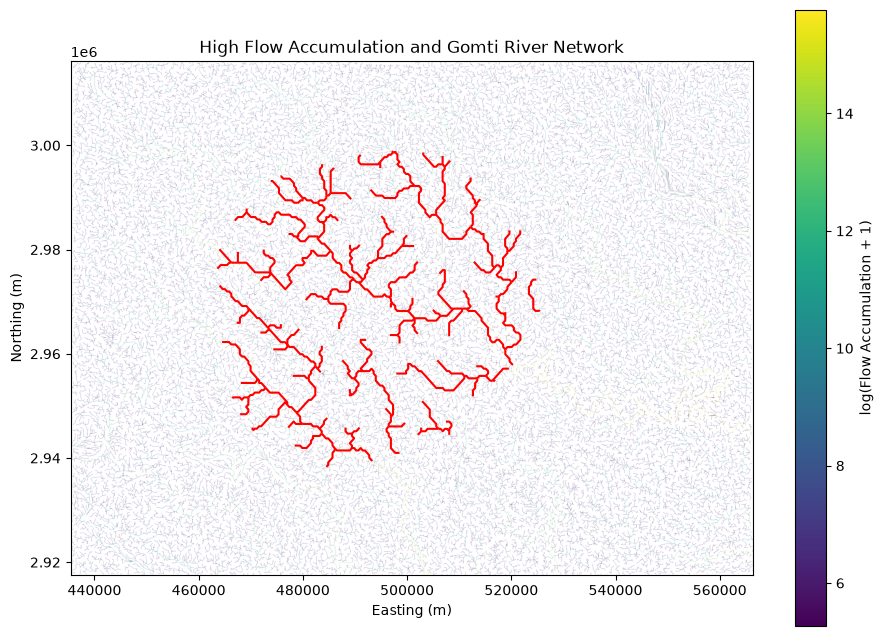

95th percentile accumulation threshold: 193.0
Gomti reaches within DEM coverage: 160


In [23]:
gomti_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_01"
    / "Gomti_River_Network_Lucknow.gpkg"
)
gomti = gpd.read_file(gomti_path)

from shapely.geometry import box

with rasterio.open(flow_accumulation_conditioned_path) as src:
    accumulation = src.read(1, masked=True)
    dem_bounds = src.bounds
    dem_crs = src.crs

# Convert DEM bounds into a polygon
dem_extent = gpd.GeoDataFrame(
    geometry=[
        box(
            dem_bounds.left,
            dem_bounds.bottom,
            dem_bounds.right,
            dem_bounds.top
        )
    ],
    crs=dem_crs
)

# Clip Gomti network to DEM coverage
gomti_clipped = gpd.clip(
    gomti.to_crs(dem_crs),
    dem_extent
)

# Use the upper 5% of accumulation values for visualization
threshold = np.percentile(
    accumulation.compressed(),
    95
)

high_accumulation = np.ma.masked_where(
    accumulation < threshold,
    accumulation
)

plt.figure(figsize=(11, 8))

plt.imshow(
    np.log1p(high_accumulation),
    extent=[
        dem_bounds.left,
        dem_bounds.right,
        dem_bounds.bottom,
        dem_bounds.top
    ]
)

gomti_clipped.plot(
    ax=plt.gca(),
    linewidth=1.5,
    color="red"
)

plt.colorbar(
    label="log(Flow Accumulation + 1)"
)

plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.title(
    "High Flow Accumulation and Gomti River Network"
)
plt.savefig(FIGURES_DIR/"High_Flow_Accumulation_&_Gomti_River_Network")
plt.show()

print("95th percentile accumulation threshold:", threshold)
print("Gomti reaches within DEM coverage:", len(gomti_clipped))

# Notebook 02 Summary — DEM Processing and Terrain/Hydrological Factors

## Objective

This notebook prepares the available Digital Elevation Model (DEM) for the
flood-susceptibility analysis and derives the required terrain and
hydrological factors.

The analysis is restricted to the spatial coverage of the available DEM.
Areas outside the available DEM coverage are not included in the
hydrological analysis.

## DEM Preparation

The DEM was:

1. Downloaded and inspected.
2. Reprojected from EPSG:4326 to EPSG:32644 (UTM Zone 44N).
3. Validated for CRS, resolution, dimensions, NoData values, and elevation
   range.
4. Clipped to the available Lucknow study-area coverage.

The final clipped elevation DEM is:

`data/processed/notebook_02/DEM_Lucknow_20km.tif`

### Final DEM characteristics

- CRS: EPSG:32644
- Resolution: approximately 28.7 m
- Dimensions: 2104 × 1882
- NoData value: -9999
- Elevation range: 99.5–143.6 m

The DEM was visually inspected and showed a continuous and spatially
reasonable elevation surface.

## Terrain Factor — Elevation

The prepared DEM itself represents the elevation factor. No additional
transformation or reclassification was performed at this stage.

## Terrain Factor — Slope

Slope was derived from the elevation DEM and expressed in degrees.

### Slope characteristics

- CRS: EPSG:32644
- Resolution: approximately 28.7 m
- Minimum slope: 0.0°
- Maximum slope: 24.64°
- Mean slope: 1.58°

The slope raster was visually inspected and showed predominantly low
terrain slopes across the study area, with localized areas of higher slope.

Output:

`data/processed/notebook_02/Slope_Lucknow_20km.tif`

## Hydrological Conditioning

Before deriving flow direction and flow accumulation, the DEM was
hydrologically conditioned by filling depressions.

The original elevation DEM was retained unchanged for the elevation factor.
The conditioned DEM was used only for hydrological derivatives.

Output:

`data/processed/notebook_02/DEM_Lucknow_hydrologically_conditioned.tif`

## D8 Flow Direction

D8 flow direction was derived from the hydrologically conditioned DEM using
WhiteboxTools.

The D8 method assigns each cell a flow direction toward one of its eight
neighbouring cells.

Output:

`data/processed/notebook_02/Flow_Direction_Lucknow_conditioned.tif`

The resulting raster contained the expected D8 pointer values:

0, 1, 2, 4, 8, 16, 32, 64, and 128.

## D8 Flow Accumulation

D8 flow accumulation was calculated from the conditioned D8 flow-direction
raster using WhiteboxTools.

The accumulation values represent the number of upstream DEM cells
contributing flow to each cell.

Final flow-accumulation statistics:

- CRS: EPSG:32644
- Resolution: approximately 28.7 m
- Minimum accumulation: 1 cell
- Maximum accumulation: 2,267,873 cells
- Mean accumulation: 1,679.68 cells
- Valid pixels: 5,222,617

The flow-accumulation raster was visualized using a logarithmic
transformation because of its large numerical range.

Output:

`data/processed/notebook_02/Flow_Accumulation_Lucknow_conditioned.tif`

## Hydrological Validation

The derived flow-accumulation pattern was compared visually with the
Gomti River network prepared in Notebook 01.

The comparison showed that the DEM-derived drainage structure contains
continuous high-accumulation pathways corresponding broadly with the
Gomti drainage corridor and associated tributary network.

This comparison is treated as a qualitative spatial sanity check rather
than a quantitative accuracy assessment.

## Outputs of Notebook 02

The main outputs produced in this notebook are:

- `DEM_Lucknow_20km.tif`
- `Slope_Lucknow_20km.tif`
- `DEM_Lucknow_hydrologically_conditioned.tif`
- `Flow_Direction_Lucknow_conditioned.tif`
- `Flow_Accumulation_Lucknow_conditioned.tif`
- `DEM_Lucknow_UTM44N.tif`

## Notebook Conclusion

The available DEM has been successfully prepared and validated for the
subsequent flood-susceptibility analysis. Elevation, slope, D8 flow
direction, and D8 flow accumulation have been derived, with the
hydrological products generated from a depression-filled DEM.

The original and conditioned DEMs are retained separately so that the
conditioning applied for hydrological modelling does not alter the
elevation factor used in the susceptibility analysis.